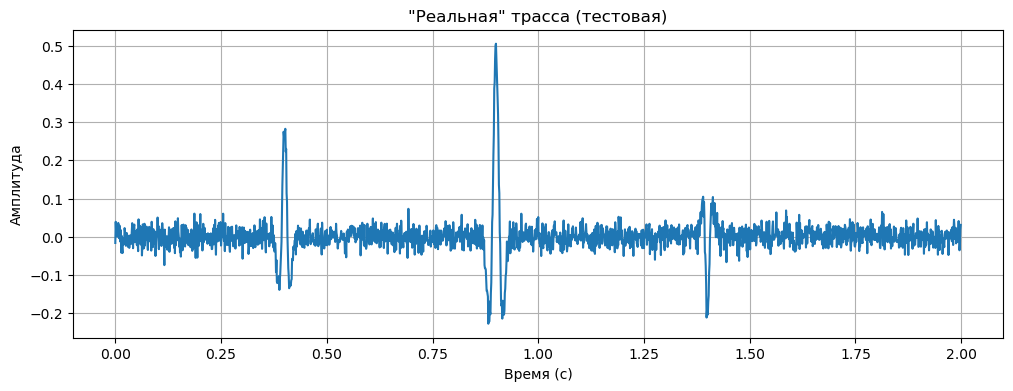

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import segyio
from scipy.signal import find_peaks, hilbert
from scipy.stats import spearmanr

def load_trace_from_sgy(filename, trace_index=0):
    """
    Загружает одну трассу из SEG-Y файла.
    
    Параметры:
    filename     : путь к .sgy файлу
    trace_index  : номер трассы (от 0)
    
    Возвращает:
    trace   : массив амплитуд
    dt_ms   : интервал дискретизации в мс
    time    : временная ось в секундах
    """
    with segyio.open(filename, 'r', ignore_geometry=True) as f:
        # Параметры из бинарного заголовка
        dt_us = f.bin[segyio.BinField.Interval]  # микросекунды
        dt_ms = dt_us / 1000
        num_samples = f.bin[segyio.BinField.Samples]
        
        # Загружаем трассу
        trace = f.trace[trace_index].astype(np.float32)
        
        # Временная ось (в секундах)
        time = np.arange(num_samples) * dt_ms / 1000
        
    print(f"Загружена трасса {trace_index} из {filename}")
    print(f"  Отсчётов: {len(trace)}")
    print(f"  dt = {dt_ms} мс")
    print(f"  Длительность: {time[-1]:.2f} с")
    
    return trace, dt_ms, time

# Пример: загружаем трассу (укажите путь к вашему файлу)
# real_trace, real_dt_ms, real_time = load_trace_from_sgy("real_data.sgy", trace_index=0)
def create_test_real_trace():
    """Создаёт искусственную 'реальную' трассу для отладки."""
    dt = 0.001
    time = np.arange(0, 2.0, dt)
    trace = np.zeros(len(time))
    
    # Добавляем три отражения с разными параметрами
    # 1й горизонт: t=0.4с, R=0.3, f=30 Гц
    t1, R1, f1 = 0.4, 0.3, 30
    w1 = (1 - 2 * (np.pi * f1 * (time - t1))**2) * np.exp(-(np.pi * f1 * (time - t1))**2)
    trace += R1 * w1
    
    # 2й горизонт: t=0.9с, R=0.5, f=25 Гц
    t2, R2, f2 = 0.9, 0.5, 25
    w2 = (1 - 2 * (np.pi * f2 * (time - t2))**2) * np.exp(-(np.pi * f2 * (time - t2))**2)
    trace += R2 * w2
    
    # 3й горизонт: t=1.4с, R=-0.2, f=35 Гц (отрицательный контраст)
    t3, R3, f3 = 1.4, -0.2, 35
    w3 = (1 - 2 * (np.pi * f3 * (time - t3))**2) * np.exp(-(np.pi * f3 * (time - t3))**2)
    trace += R3 * w3
    
    # Добавляем шум
    trace += np.random.normal(0, 0.02, len(trace))
    
    return trace, dt, time

# Создаём тестовую трассу
real_trace, real_dt_ms, real_time = create_test_real_trace()

plt.figure(figsize=(12, 4))
plt.plot(real_time, real_trace)
plt.title('"Реальная" трасса (тестовая)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

Найдено событий: 326
Оценка доминантной частоты: 30.7 Гц

Выделенные события:
--------------------------------------------------
  t = 0.001 с, A = 0.039, positive
  t = 0.017 с, A = -0.043, negative
  t = 0.022 с, A = 0.022, positive
  t = 0.033 с, A = -0.029, negative
  t = 0.040 с, A = 0.035, positive
  t = 0.042 с, A = -0.030, negative
  t = 0.045 с, A = 0.032, positive
  t = 0.054 с, A = -0.038, negative
  t = 0.055 с, A = 0.045, positive
  t = 0.063 с, A = -0.049, negative
  t = 0.065 с, A = 0.032, positive
  t = 0.067 с, A = -0.031, negative
  t = 0.069 с, A = 0.034, positive
  t = 0.077 с, A = -0.035, negative
  t = 0.080 с, A = 0.026, positive
  t = 0.085 с, A = -0.036, negative
  t = 0.086 с, A = 0.039, positive
  t = 0.095 с, A = -0.050, negative
  t = 0.100 с, A = 0.050, positive
  t = 0.103 с, A = -0.033, negative
  t = 0.111 с, A = 0.035, positive
  t = 0.116 с, A = -0.074, negative
  t = 0.117 с, A = 0.018, positive
  t = 0.123 с, A = -0.034, negative
  t = 0.127 с, A = 

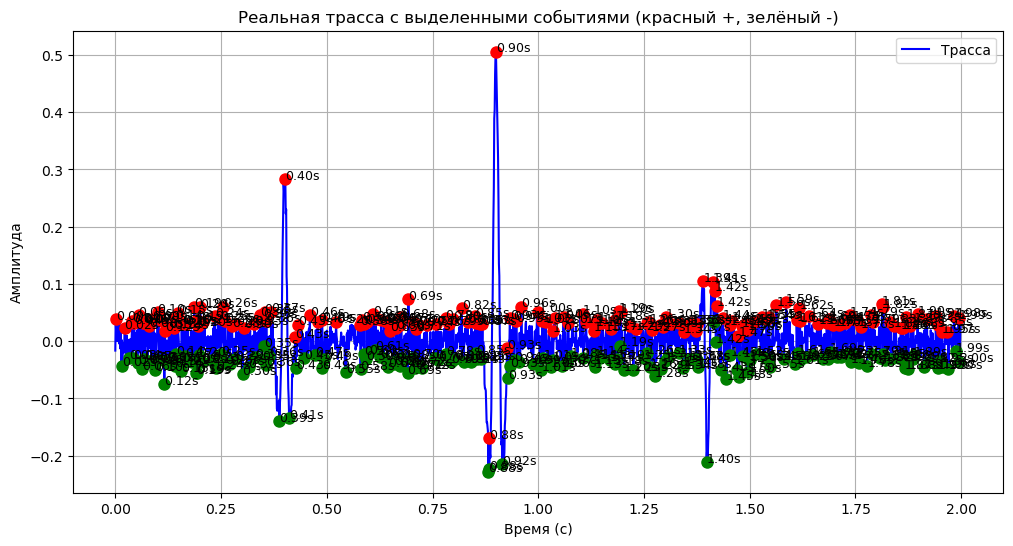

In [2]:
def analyze_trace(trace, time, prominence=0.05):
    """
    Анализирует трассу: находит пики (события), оценивает их параметры.
    
    Возвращает:
    events : список словарей с параметрами событий
    """
    # Находим пики (положительные и отрицательные)
    peaks_pos, props_pos = find_peaks(trace, prominence=prominence)
    peaks_neg, props_neg = find_peaks(-trace, prominence=prominence)
    
    events = []
    
    # Положительные пики
    for p in peaks_pos:
        events.append({
            'time': time[p],
            'amplitude': trace[p],
            'type': 'positive',
            'index': p
        })
    
    # Отрицательные пики (берём абсолютное значение амплитуды)
    for p in peaks_neg:
        events.append({
            'time': time[p],
            'amplitude': trace[p],  # отрицательное
            'type': 'negative',
            'index': p
        })
    
    # Сортируем по времени
    events.sort(key=lambda x: x['time'])
    
    # Оцениваем доминантную частоту (через огибающую)
    analytic = hilbert(trace)
    envelope = np.abs(analytic)
    instantaneous_freq = np.diff(np.unwrap(np.angle(analytic))) / (2 * np.pi * (time[1]-time[0]))
    dominant_freq = np.median(instantaneous_freq[envelope[1:] > 0.5 * np.max(envelope)])
    
    print(f"Найдено событий: {len(events)}")
    print(f"Оценка доминантной частоты: {dominant_freq:.1f} Гц")
    
    return events, dominant_freq

# Анализируем реальную трассу
events, estimated_freq = analyze_trace(real_trace, real_time, prominence=0.05)

print("\nВыделенные события:")
print("-" * 50)
for e in events:
    print(f"  t = {e['time']:.3f} с, A = {e['amplitude']:.3f}, {e['type']}")
plt.figure(figsize=(12, 6))
plt.plot(real_time, real_trace, 'b-', label='Трасса')

# Отмечаем пики
for e in events:
    color = 'r' if e['type'] == 'positive' else 'g'
    plt.plot(e['time'], e['amplitude'], 'o', color=color, markersize=8)
    plt.text(e['time'], e['amplitude'], f"{e['time']:.2f}s", fontsize=9)

plt.title('Реальная трасса с выделенными событиями (красный +, зелёный -)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()

In [3]:
class AdjustableSeismicModel:
    """
    Физическая модель с регулируемыми параметрами.
    Позволяет изменять глубины, скорости, плотности и частоту.
    """
    
    def __init__(self, dt=0.001, total_time=2.0):
        self.dt = dt
        self.total_time = total_time
        self.time = np.arange(0, total_time, dt)
        
        # Параметры модели (будут установлены позже)
        self.depths = None      # глубины границ (м)
        self.velocities = None  # скорости в слоях (м/с)
        self.densities = None   # плотности в слоях (кг/м³)
        self.wavelet_freq = 30  # частота вейвлета (Гц)
        self.noise_std = 0.0    # уровень шума
        
    def set_horizons(self, depths, velocities, densities):
        """Устанавливает геометрию слоёв."""
        self.depths = np.array(depths)
        self.velocities = np.array(velocities)
        self.densities = np.array(densities)
        
    def set_wavelet_freq(self, freq):
        self.wavelet_freq = freq
        
    def set_noise(self, noise_std):
        self.noise_std = noise_std
        
    def compute_reflectivity(self):
        """Вычисляет коэффициенты отражения по импедансам."""
        impedances = self.densities * self.velocities
        
        coeffs = []
        times = []
        cum_time = 0
        prev_depth = 0
        
        for i in range(len(self.depths)):
            # Коэффициент отражения
            Z_up = impedances[i]
            Z_down = impedances[i+1]
            R = (Z_down - Z_up) / (Z_down + Z_up)
            coeffs.append(R)
            
            # Время прихода
            thickness = self.depths[i] - prev_depth
            v = self.velocities[i]
            cum_time += 2 * thickness / v
            times.append(cum_time)
            prev_depth = self.depths[i]
            
        return np.array(coeffs), np.array(times)
    
    def generate_trace(self):
        """Генерирует синтетическую трассу с текущими параметрами."""
        # Получаем коэффициенты отражения
        coeffs, times = self.compute_reflectivity()
        
        # Создаём вейвлет
        wavelet_time = np.arange(-0.1, 0.1, self.dt)
        tau = np.pi * self.wavelet_freq * wavelet_time
        wavelet = (1 - 2 * tau**2) * np.exp(-tau**2)
        
        # Формируем серию коэффициентов
        reflectivity = np.zeros(len(self.time))
        for t, r in zip(times, coeffs):
            idx = int(t / self.dt)
            if idx < len(reflectivity):
                reflectivity[idx] = r
        
        # Свёртка
        trace = np.convolve(reflectivity, wavelet, mode='same')
        
        # Шум
        if self.noise_std > 0:
            trace += np.random.normal(0, self.noise_std, len(trace))
            
        return trace, times, coeffs
    
    def compare_with_real(self, real_trace):
        """Сравнивает синтетику с реальной трассой."""
        synth_trace, _, _ = self.generate_trace()
        min_len = min(len(synth_trace), len(real_trace))
        
        corr = np.corrcoef(synth_trace[:min_len], real_trace[:min_len])[0, 1]
        spearman = spearmanr(synth_trace[:min_len], real_trace[:min_len])[0]
        mse = np.mean((synth_trace[:min_len] - real_trace[:min_len])**2)
        
        return {
            'pearson': corr,
            'spearman': spearman,
            'mse': mse,
            'trace': synth_trace
        }
    
    def plot_comparison(self, real_trace):
        """Визуализирует сравнение с реальной трассой."""
        synth_trace, times, coeffs = self.generate_trace()
        min_len = min(len(synth_trace), len(real_trace))
        time_axis = self.time[:min_len]
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        # Трассы
        axes[0].plot(time_axis, real_trace[:min_len], 'b-', label='Реальная', alpha=0.8)
        axes[0].plot(time_axis, synth_trace[:min_len], 'r-', label='Синтетика', alpha=0.8)
        for t in times:
            axes[0].axvline(x=t, color='gray', linestyle='--', alpha=0.5)
        axes[0].set_title(f'Сравнение трасс (корр = {self.compare_with_real(real_trace)["pearson"]:.3f})')
        axes[0].set_xlabel('Время (с)')
        axes[0].legend()
        axes[0].grid(True)
        
        # Разность
        diff = synth_trace[:min_len] - real_trace[:min_len]
        axes[1].plot(time_axis, diff, 'g-')
        axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[1].set_title(f'Разность (MSE = {self.compare_with_real(real_trace)["mse"]:.6f})')
        axes[1].set_xlabel('Время (с)')
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()

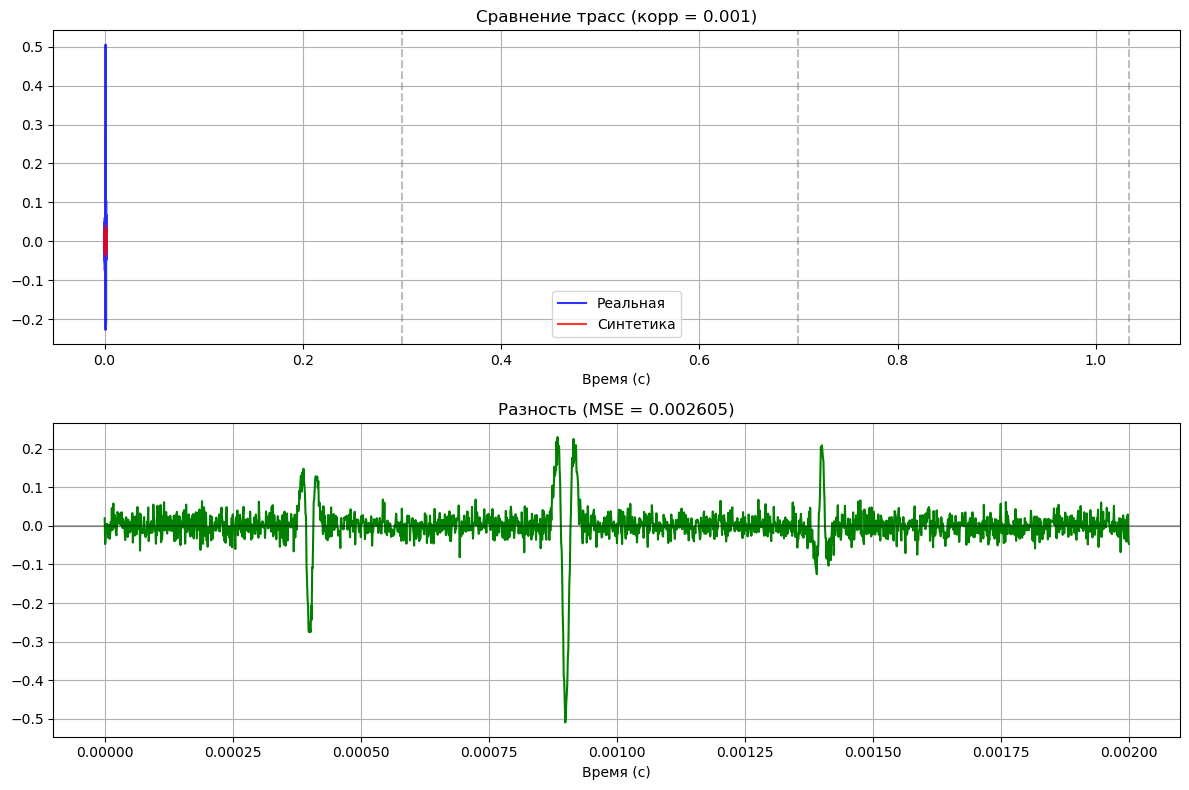

Начальные метрики: Pearson = 0.016, MSE = 0.002553
f = 20 Гц -> Pearson = 0.020
f = 25 Гц -> Pearson = -0.008


In [ ]:
# Создаём модель с теми же параметрами дискретизации, что у реальной трассы
model = AdjustableSeismicModel(dt=real_dt_ms/1000, total_time=real_time[-1])

# Начальное приближение (по событиям из шага 2)
# Для примера: у нас 3 горизонта
initial_depths = [300, 800, 1300]  # примерные глубины (м)
initial_velocities = [2000, 2500, 3000, 3500]  # по слоям
initial_densities = [2100, 2200, 2300, 2400]

model.set_horizons(initial_depths, initial_velocities, initial_densities)
model.set_wavelet_freq(estimated_freq)
model.set_noise(0.01)

# Смотрим, что получилось
model.plot_comparison(real_trace)
metrics = model.compare_with_real(real_trace)
print(f"Начальные метрики: Pearson = {metrics['pearson']:.3f}, MSE = {metrics['mse']:.6f}")
# Пробуем разные частоты
freqs = [20, 25, 30, 35, 40]
best_freq = estimated_freq
best_corr = -1

for f in freqs:
    model.set_wavelet_freq(f)
    metrics = model.compare_with_real(real_trace)
    print(f"f = {f} Гц -> Pearson = {metrics['pearson']:.3f}")
    if metrics['pearson'] > best_corr:
        best_corr = metrics['pearson']
        best_freq = f

model.set_wavelet_freq(best_freq)
print(f"\nЛучшая частота: {best_freq} Гц (корр = {best_corr:.3f})")
def adjust_amplitudes(model, real_trace, event_times, target_amplitudes):
    """
    Подбирает коэффициенты отражения под целевые амплитуды.
    """
    # Получаем текущие времена и коэффициенты
    _, current_times = model.compute_reflectivity()
    
    # Для каждого события подбираем множитель к плотности
    print("Настройка амплитуд...")
    
    # Пробуем изменить плотности на границах
    densities_adjusted = model.densities.copy()
    
    for i, t_event in enumerate(event_times):
        if i < len(current_times):
            # Находим ближайший горизонт по времени
            idx = np.argmin(np.abs(np.array(current_times) - t_event))
            # Меняем плотность нижнего слоя (грубо)
            if idx + 1 < len(densities_adjusted):
                # Эмпирический коэффициент
                factor = 1 + 0.5 * target_amplitudes[i] / model.densities[idx+1]
                densities_adjusted[idx+1] *= factor
    
    model.set_horizons(model.depths, model.velocities, densities_adjusted)
    return model
def adjust_times(model, real_trace, event_times):
    """
    Подбирает скорости/глубины, чтобы времена прихода совпали.
    """
    synth_trace, synth_times, _ = model.generate_trace()
    
    print("Текущие времена:", [f"{t:.3f}" for t in synth_times])
    print("Целевые времена:", [f"{t:.3f}" for t in event_times])
    
    # Для каждого горизонта подбираем поправку
    depths_adjusted = model.depths.copy()
    
    for i, (synth_t, target_t) in enumerate(zip(synth_times, event_times)):
        if i < len(depths_adjusted):
            # Относительная поправка глубины
            correction = (target_t - synth_t) / synth_t if synth_t > 0 else 0
            depths_adjusted[i] *= (1 + correction)
            print(f"  Горизонт {i}: глубина {model.depths[i]:.0f} -> {depths_adjusted[i]:.0f} м")
    
    # Обновляем глубины, сохраняя скорости и плотности
    model.set_horizons(depths_adjusted, model.velocities, model.densities)
    return model
# Получаем целевые времена и амплитуды из реальной трассы
target_times = [e['time'] for e in events if abs(e['amplitude']) > 0.05]
target_amplitudes = [e['amplitude'] for e in events if abs(e['amplitude']) > 0.05]

print("Целевые параметры:")
print(f"  Времена: {[f'{t:.3f}' for t in target_times]}")
print(f"  Амплитуды: {[f'{a:.3f}' for a in target_amplitudes]}")

# Итеративный цикл
n_iterations = 5
history = []

for iteration in range(n_iterations):
    print(f"\n{'='*50}")
    print(f"Итерация {iteration + 1}")
    print('='*50)
    
    # 1. Сначала корректируем времена
    model = adjust_times(model, real_trace, target_times)
    
    # 2. Затем амплитуды
    # model = adjust_amplitudes(model, real_trace, target_times, target_amplitudes)
    
    # 3. Оцениваем результат
    metrics = model.compare_with_real(real_trace)
    history.append(metrics)
    
    print(f"\nРезультат итерации {iteration + 1}:")
    print(f"  Pearson: {metrics['pearson']:.4f}")
    print(f"  MSE: {metrics['mse']:.6f}")
    
    # 4. Визуализируем
    model.plot_comparison(real_trace)

# Финальные результаты
print("\n" + "="*50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*50)

final_metrics = model.compare_with_real(real_trace)
print(f"Финальный Pearson: {final_metrics['pearson']:.4f}")
print(f"Финальный Spearman: {final_metrics['spearman']:.4f}")
print(f"Финальный MSE: {final_metrics['mse']:.6f}")

# Выводим итоговую модель
_, final_times, final_coeffs = model.generate_trace()
print("\nИтоговая модель:")
print(f"  Глубины: {model.depths}")
print(f"  Скорости: {model.velocities}")
print(f"  Плотности: {model.densities}")
print(f"  Времена прихода: {[f'{t:.3f}' for t in final_times]}")
print(f"  Коэффициенты отражения: {[f'{r:.3f}' for r in final_coeffs]}")
print(f"  Частота вейвлета: {model.wavelet_freq} Гц")